In [2]:
%load_ext autoreload
%autoreload 2

In [1]:
from src.data_ingestion import load_raw_data
from src.feature_engineering import (
    build_feature_table,
    add_lagged_returns,
    add_rolling_volatility,
    add_trade_intensity,
)
from src.target_construction import add_returns, add_future_return, add_direction_label

df = load_raw_data("aapl_trades_2022-09-20.parquet")

feature_table = build_feature_table(df)
feature_table = add_returns(feature_table)
feature_table = add_future_return(feature_table, horizon=1)
feature_table = add_direction_label(feature_table, horizon=1)
feature_table = add_lagged_returns(feature_table)
feature_table = add_rolling_volatility(feature_table)
feature_table = add_trade_intensity(feature_table)

print(feature_table.columns)
feature_table.select([
    "second",
    "close",
    "return_1s",
    "future_return_1s",
    "direction_1s",
    "return_lag1",
    "return_lag5",
    "volatility_10s",
    "trade_intensity_10s",
]).head(15)

['second', 'open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap', 'symbol', 'buy_volume', 'sell_volume', 'neutral_volume', 'order_flow_imbalance', 'return_1s', 'future_return_1s', 'direction_1s', 'return_lag1', 'return_lag5', 'volatility_10s', 'volatility_30s', 'trade_intensity_10s']


second,close,return_1s,future_return_1s,direction_1s,return_lag1,return_lag5,volatility_10s,trade_intensity_10s
"datetime[ns, UTC]",f64,f64,f64,i32,f64,f64,f64,f64
2022-09-20 08:00:19 UTC,154.27,null,0.00013,1,null,null,null,null
2022-09-20 08:00:22 UTC,154.29,0.00013,-0.001426,0,null,null,null,null
2022-09-20 08:00:39 UTC,154.07,-0.001426,0.0,0,0.00013,null,null,null
2022-09-20 08:00:47 UTC,154.07,0.0,0.0,0,-0.001426,null,null,null
2022-09-20 08:00:48 UTC,154.07,0.0,0.0,0,0.0,null,null,null
…,…,…,…,…,…,…,…,…
2022-09-20 08:01:22 UTC,154.0,-0.000065,0.00013,1,-0.000065,0.0,0.000454,3.2
2022-09-20 08:01:24 UTC,154.02,0.00013,0.0,0,-0.000065,-0.000325,0.000454,3.3
2022-09-20 08:01:27 UTC,154.02,0.0,0.000195,1,0.00013,0.0,0.000116,3.5


In [3]:
from src.feature_engineering import add_volume_zscore

feature_table = add_volume_zscore(feature_table)

feature_table.select([
    "second",
    "volume",
    "volume_zscore"
]).head(15)

second,volume,volume_zscore
"datetime[ns, UTC]",u32,f64
2022-09-20 08:00:19 UTC,120,null
2022-09-20 08:00:22 UTC,2,null
2022-09-20 08:00:39 UTC,5,null
2022-09-20 08:00:47 UTC,5,null
2022-09-20 08:00:48 UTC,8,null
…,…,…
2022-09-20 08:01:22 UTC,200,null
2022-09-20 08:01:24 UTC,190,null
2022-09-20 08:01:27 UTC,220,null


| Check                 | What it tells us           |
| --------------------- | -------------------------- |
| return distribution   | data quality               |
| up/down balance       | classification feasibility |
| missing values        | pipeline correctness       |
| autocorrelation       | microstructure behavior    |
| volatility clustering | regime structure           |


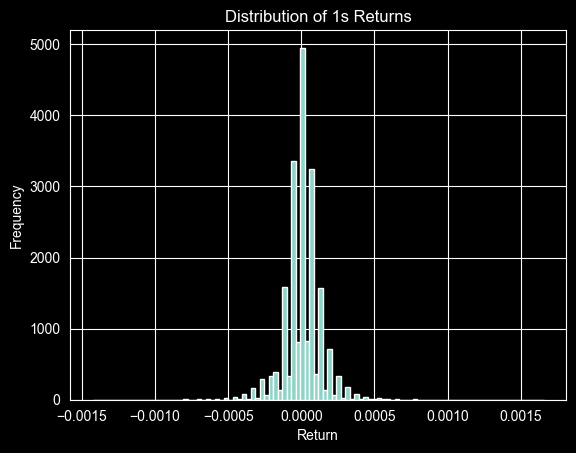

In [4]:
import matplotlib.pyplot as plt

returns = feature_table.select("return_1s").drop_nulls()

plt.hist(returns.to_pandas(), bins=100)
plt.title("Distribution of 1s Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()

In [5]:
feature_table.select("direction_1s").drop_nulls().group_by("direction_1s").len()

direction_1s,len
i32,u32
1,7679
0,12671


In [6]:
feature_table.null_count()

second,open,high,low,close,volume,trade_count,vwap,symbol,buy_volume,sell_volume,neutral_volume,order_flow_imbalance,return_1s,future_return_1s,direction_1s,return_lag1,return_lag5,volatility_10s,volatility_30s,trade_intensity_10s,volume_mean_30,volume_std_30,volume_zscore
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,2,6,10,30,9,29,29,29


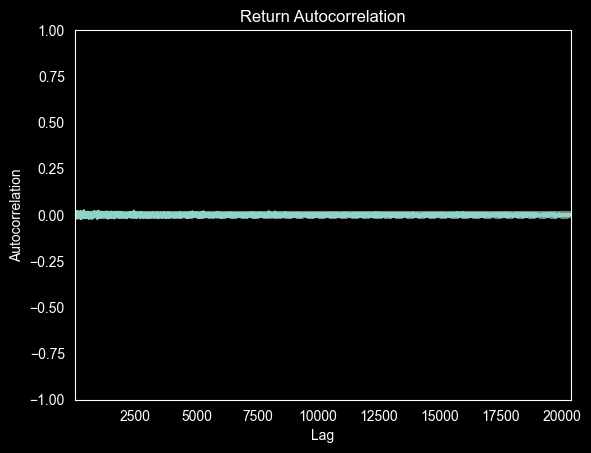

In [7]:
import pandas as pd

returns = feature_table.select("return_1s").drop_nulls().to_pandas()

pd.plotting.autocorrelation_plot(returns["return_1s"])
plt.title("Return Autocorrelation")
plt.show()

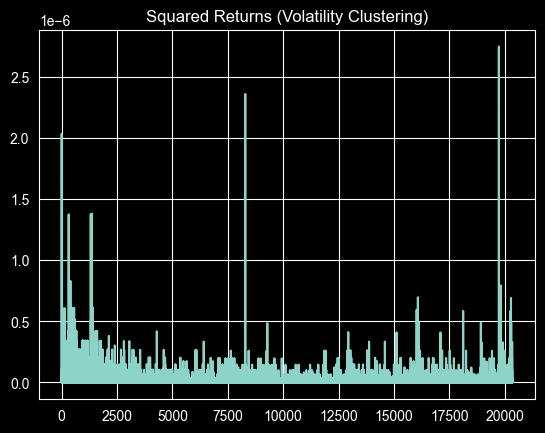

In [8]:
vol = feature_table.select("return_1s").drop_nulls().to_pandas()

plt.plot(vol["return_1s"]**2)
plt.title("Squared Returns (Volatility Clustering)")
plt.show()

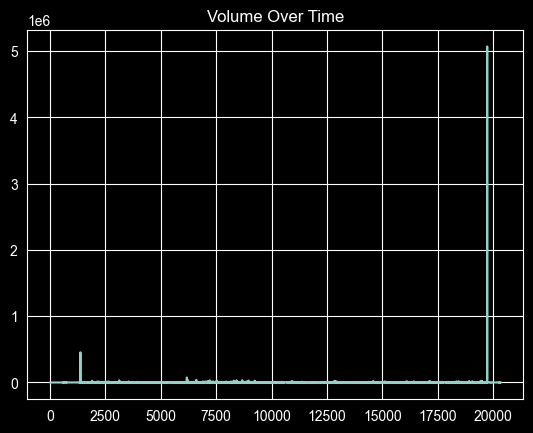

In [9]:
# optional:volume spikes (may see activity burst)
plt.plot(feature_table.select("volume").to_pandas())
plt.title("Volume Over Time")
plt.show()

In [10]:
from src.data_cleaning import clean_trade_data, summarize_cleaning

clean_df = clean_trade_data(
    df,
    remove_dupes=True,
    filter_bad_prices=True,
    filter_bad_sizes=True,
    filter_bad_jumps=False,
    regular_trading_hours_only=False,
)

summary = summarize_cleaning(df, clean_df)
summary

before_rows,after_rows,removed_rows,removed_pct
i64,i64,i64,f64
166737,166737,0,0.0


In [11]:
print("Before:", df.shape)
print("After: ", clean_df.shape)

Before: (166737, 14)
After:  (166737, 14)


In [ ]:
df.select("action").unique()

In [ ]:
df.select("side").unique()

In [ ]:
df.filter(pl.col("depth") == 0).shape

In [1]:
df.group_by("side").len()

NameError: name 'df' is not defined

In [ ]:
from src.bar_construction import build_one_second_bars

bars = build_one_second_bars(df)

print(bars.shape)
bars.head()

In [ ]:
df.select(["price","size"]).head()

In [ ]:
from src.bar_construction import build_one_second_bars

bars = build_one_second_bars(df)
print(bars.shape)
bars.head()

In [ ]:
bars.select(["second", "open", "high", "low", "close", "volume", "trade_count", "vwap"]).head()

In [ ]:
from src.feature_engineering import build_order_flow_features

flow_features = build_order_flow_features(df)
print(flow_features.shape)
flow_features.head()

In [2]:
from src.feature_engineering import build_feature_table

feature_table = build_feature_table(df)
print(feature_table.shape)
feature_table.head()

ImportError: cannot import name 'build_feature_table' from 'src.feature_engineering' (C:\Users\95393\PycharmProjects\equity-microstructure-alpha\src\feature_engineering.py)

In [5]:
from src.target_construction import add_returns, add_future_return, add_direction_label

feature_table = add_returns(feature_table)
feature_table = add_future_return(feature_table, horizon=1)
feature_table = add_direction_label(feature_table, horizon=1)

feature_table.select([
    "second",
    "close",
    "return_1s",
    "future_return_1s",
    "direction_1s"
]).head(10)

second,close,return_1s,future_return_1s,direction_1s
"datetime[ns, UTC]",f64,f64,f64,i32
2022-09-20 08:00:19 UTC,154.27,null,0.00013,1
2022-09-20 08:00:22 UTC,154.29,0.00013,-0.001426,0
2022-09-20 08:00:39 UTC,154.07,-0.001426,0.0,0
2022-09-20 08:00:47 UTC,154.07,0.0,0.0,0
2022-09-20 08:00:48 UTC,154.07,0.0,0.0,0
2022-09-20 08:01:09 UTC,154.07,0.0,-0.000325,0
2022-09-20 08:01:13 UTC,154.02,-0.000325,0.0,0
2022-09-20 08:01:14 UTC,154.02,0.0,0.0,0
2022-09-20 08:01:15 UTC,154.02,0.0,-0.000065,0


In [ ]:
from src.feature_engineering import (
    add_lagged_returns,
    add_rolling_volatility,
    add_trade_intensity
)

feature_table = add_lagged_returns(feature_table)
feature_table = add_rolling_volatility(feature_table)
feature_table = add_trade_intensity(feature_table)

feature_table.select([
    "second",
    "return_1s",
    "return_lag1",
    "return_lag5",
    "volatility_10s",
    "trade_intensity_10s"
]).head(15)

In [3]:
from src.data_ingestion import load_raw_data
from src.feature_engineering import (
    build_feature_table,
    add_lagged_returns,
    add_rolling_volatility,
    add_trade_intensity,
)
from src.target_construction import add_returns, add_future_return, add_direction_label

df = load_raw_data("aapl_trades_2022-09-20.parquet")

feature_table = build_feature_table(df)
feature_table = add_returns(feature_table)
feature_table = add_future_return(feature_table, horizon=1)
feature_table = add_direction_label(feature_table, horizon=1)
feature_table = add_lagged_returns(feature_table)
feature_table = add_rolling_volatility(feature_table)
feature_table = add_trade_intensity(feature_table)

print(feature_table.columns)
feature_table.select([
    "second",
    "close",
    "return_1s",
    "future_return_1s",
    "direction_1s",
    "return_lag1",
    "return_lag5",
    "volatility_10s",
    "trade_intensity_10s",
]).head(15)

['second', 'open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap', 'symbol', 'buy_volume', 'sell_volume', 'neutral_volume', 'order_flow_imbalance', 'return_1s', 'future_return_1s', 'direction_1s', 'return_lag1', 'return_lag5', 'volatility_10s', 'volatility_30s', 'trade_intensity_10s']


second,close,return_1s,future_return_1s,direction_1s,return_lag1,return_lag5,volatility_10s,trade_intensity_10s
"datetime[ns, UTC]",f64,f64,f64,i32,f64,f64,f64,f64
2022-09-20 08:00:19 UTC,154.27,null,0.00013,1,null,null,null,null
2022-09-20 08:00:22 UTC,154.29,0.00013,-0.001426,0,null,null,null,null
2022-09-20 08:00:39 UTC,154.07,-0.001426,0.0,0,0.00013,null,null,null
2022-09-20 08:00:47 UTC,154.07,0.0,0.0,0,-0.001426,null,null,null
2022-09-20 08:00:48 UTC,154.07,0.0,0.0,0,0.0,null,null,null
…,…,…,…,…,…,…,…,…
2022-09-20 08:01:22 UTC,154.0,-0.000065,0.00013,1,-0.000065,0.0,0.000454,3.2
2022-09-20 08:01:24 UTC,154.02,0.00013,0.0,0,-0.000065,-0.000325,0.000454,3.3
2022-09-20 08:01:27 UTC,154.02,0.0,0.000195,1,0.00013,0.0,0.000116,3.5
